In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import xarray as xr
import geopandas as gpd
import cartopy.crs as ccrs
from shapely.geometry import box

In [3]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import xarray as xr


def julian_to_datetime(julian, year):
    base = pd.Timestamp(f"{year}-01-01")
    return base + pd.to_timedelta(julian - 1, unit="D")


def read_downcast_txt(file, year=None):
    file = Path(file)

    # Try to parse year from filename like nbp1704_01d.txt or nbp_1704_01d.txt
    if year is None:
        match = re.search(r"nbp_?(\d{2})", file.stem)
        if match is None:
            raise ValueError(
                "Could not infer year from filename. "
                "Pass year explicitly, e.g. read_downcast_txt(file, year=2017)"
            )
        year = int("20" + match.group(1))

    columns = [
        "press", "depth", "time_julian", "lat", "lon",
        "temp", "cond", "O2", "theta", "sal", "sigma_theta",
        "fluor", "PAR", "beam_trans", "beam_atten", "FLBB1", "FLBB2"
    ]

    df = pd.read_csv(
        file,
        sep=r"\s+",
        skiprows=1,
        names=columns,
        engine="python"
    )

    # Replace common bad values
    df = df.replace([-999, -9999, -99, 1e35], np.nan)

    # Convert Julian day to datetime
    df["datetime"] = julian_to_datetime(df["time_julian"], year)

    # Save scalar metadata BEFORE grouping
    lat_mean = df["lat"].mean()
    lon_mean = df["lon"].mean()
    time_mean = df["datetime"].mean()

    # Sort by pressure
    df = df.sort_values("press")

    # Drop scalar metadata columns before pressure grouping
    df = df.drop(columns=["lat", "lon", "time_julian", "datetime"])

    # Average duplicate pressure bins
    df = df.groupby("press", as_index=False).mean(numeric_only=True)

    # Convert to xarray with pressure as dimension
    ds = df.set_index("press").to_xarray()

    # Add scalar coordinates
    ds = ds.assign_coords(
        lat=float(lat_mean),
        lon=float(lon_mean),
        time=pd.to_datetime(time_mean),
    )

    ds.attrs["source_file"] = file.name
    ds.attrs["year"] = year

    return ds

In [4]:
folder = "/Users/mblan/Documents/TNB_Research/data/PIPERS_CTD_2017/final_ascii_v2"

In [5]:
folder + "/nbp1704_01d.txt"

'/Users/mblan/Documents/TNB_Research/data/PIPERS_CTD_2017/final_ascii_v2/nbp1704_01d.txt'

In [6]:
ds = read_downcast_txt(folder + "/nbp1704_01d.txt")

In [7]:
ds

<xarray.Dataset> Size: 227kB
Dimensions:      (press: 2024)
Coordinates:
  * press        (press) int64 16kB 8 9 10 11 12 13 ... 2027 2028 2029 2030 2031
    lat          float64 8B -60.0
    lon          float64 8B 170.0
    time         datetime64[ns] 8B 2017-04-16T00:20:09.600000
Data variables: (12/13)
    depth        (press) float64 16kB 7.92 8.91 9.9 ... 2.001e+03 2.002e+03
    temp         (press) float64 16kB 5.301 5.301 5.301 ... 1.796 1.794 1.791
    cond         (press) float64 16kB 3.272 3.272 3.272 ... 3.127 3.127 3.127
    O2           (press) float64 16kB 6.99 6.995 6.995 ... 4.418 4.422 4.427
    theta        (press) float64 16kB 5.301 5.301 5.3 5.3 ... 1.659 1.657 1.655
    sal          (press) float64 16kB 33.84 33.84 33.84 ... 34.74 34.74 34.74
    ...           ...
    fluor        (press) float64 16kB 0.226 0.227 0.23 ... 0.042 0.038 0.042
    PAR          (press) float64 16kB 133.0 119.0 115.0 ... 0.000298 0.000293
    beam_trans   (press) float64 16kB 99.4 99.41 99.4 99.4 ... 100.6 100.6 100.6
    beam_atten   (press) float64 16kB 0.0242 0.0238 0.024 ... -0.0231 -0.0233
    FLBB1        (press) float64 16kB 0.1107 0.1113 0.1152 ... 0.0682 0.0673
    FLBB2        (press) float64 16kB 0.1731 0.1753 0.1805 ... 0.1324 0.1334
Attributes:
    source_file:  nbp1704_01d.txt
    year:         2017

In [8]:
from pathlib import Path
import re

folder = Path("/Users/mblan/Documents/TNB_Research/data/PIPERS_CTD_2017/final_ascii_v2")

casts = {}

for file in sorted(folder.glob("*.txt")):

    stem = file.stem  # filename without .txt

    # Only keep files ending in d
    if not stem.endswith("d"):
        continue

    # Extract station number before the final "d"
    # Works for filenames like:
    # nbp1704_01d
    # nbp_1704_01d
    match = re.search(r"_(\d{2})d$", stem)

    if match is None:
        print(f"Skipping unclear filename: {file.name}")
        continue

    station = int(match.group(1))  # "01" -> 1

    ds = read_downcast_txt(file)
    ds = ds.assign_coords(station=station)

    casts[station] = ds

In [9]:
casts.keys()

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58])

In [10]:
cast = casts[50]

Text(0.5, 0, 'Sal')

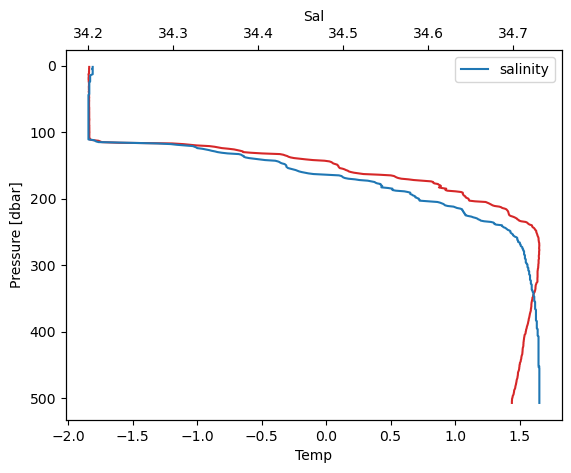

In [11]:
fig, ax = plt.subplots()
ax.plot(cast.temp,cast.press,color='tab:red',label='Temp')
ax.invert_yaxis()
ax1 = ax.twiny()
ax1.plot(cast.sal,cast.press,color='tab:blue',label='salinity')
plt.legend()
ax.set_ylabel('Pressure [dbar]')
ax.set_xlabel('Temp')
ax1.set_xlabel('Sal')

In [12]:
casts[58]

<xarray.Dataset> Size: 57kB
Dimensions:      (press: 506)
Coordinates:
  * press        (press) int64 4kB 3 4 5 6 7 8 9 ... 502 503 504 505 506 507 508
    lat          float64 8B -66.15
    lon          float64 8B -175.3
    time         datetime64[ns] 8B 2017-06-05T09:53:16.799999744
    station      int64 8B 58
Data variables: (12/13)
    depth        (press) float64 4kB 2.97 3.96 4.95 5.94 ... 500.4 501.4 502.4
    temp         (press) float64 4kB -1.78 -1.782 -1.785 ... 1.445 1.444 1.444
    cond         (press) float64 4kB 2.681 2.68 2.68 2.68 ... 3.031 3.031 3.031
    O2           (press) float64 4kB 7.896 7.901 7.898 ... 4.559 4.569 4.571
    theta        (press) float64 4kB -1.78 -1.782 -1.785 ... 1.419 1.418 1.418
    sal          (press) float64 4kB 34.0 34.0 34.0 34.0 ... 34.73 34.73 34.73
    ...           ...
    fluor        (press) float64 4kB 0.255 0.21 0.218 ... 0.048 0.042 0.047
    PAR          (press) float64 4kB 0.0224 0.0363 0.0284 ... 0.00028 0.000292
    beam_trans   (press) float64 4kB 99.87 99.82 99.85 ... 100.5 100.5 100.5
    beam_atten   (press) float64 4kB 0.0053 0.0073 0.0059 ... -0.021 -0.0206
    FLBB1        (press) float64 4kB nan nan nan nan nan ... nan nan nan nan nan
    FLBB2        (press) float64 4kB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    source_file:  nbp1704_58d.txt
    year:         2017

In [13]:
bath = xr.open_dataset(
    "/Users/mblan/Documents/research/data/gebco_2024_n-66.2651_s-87.7985_w159.418_e213.2403.nc"
)

gdf = gpd.read_file(
    "/Users/mblan/Documents/research/data/add_coastline_high_res_polygon_v7.2/add_coastline_high_res_polygon_v7.2.shp"
)

# make sure coastline is lon/lat
if gdf.crs is not None:
    gdf = gdf.to_crs("EPSG:4326")

# repair invalid geometries
gdf["geometry"] = gdf.geometry.buffer(0)

ice = gdf[gdf["surface"].isin(["ice shelf", "ice tongue"])]
land = gdf[gdf["surface"].isin(["land"])]

In [14]:
def TNB_study_site(
    bath,
    ice,
    land,
    lon_min=162,
    lon_max=170,
    lat_min=-75.75,
    lat_max=-74.25,
    figsize=(8, 6),
    central_longitude=165,
    contour_levels=None,
    n_contours=5,
    contour_min=200,
    contour_max=1200,
    contour_color="black",
    contour_lw=0.7,
    label_contours=True,
    gridline_lons=None,
    gridline_lats=None,
):
    """
    Create a reusable Terra Nova Bay / Ross Sea study-site map.

    Parameters
    ----------
    bath : xarray.Dataset
        GEBCO bathymetry dataset with variables lon, lat, elevation.
    ice, land : geopandas.GeoDataFrame
        SCAR ADD clipped/unclipped ice and land polygons.
    lon_min, lon_max, lat_min, lat_max : float
        Map extent in lon/lat.
    contour_levels : list or array, optional
        Specific bathymetry contour levels in positive meters.
        Example: [400, 600, 800, 1000]
    n_contours : int
        Number of contours if contour_levels is not provided.
    contour_min, contour_max : float
        Min/max depth contours if contour_levels is not provided.
    """

    # -----------------------------
    # Projection / figure
    # -----------------------------
    proj = ccrs.SouthPolarStereo(central_longitude=central_longitude)

    fig, ax = plt.subplots(
        figsize=figsize,
        subplot_kw={"projection": proj},
        constrained_layout=True
    )

    ax.set_extent(
        [lon_min, lon_max, lat_min, lat_max],
        crs=ccrs.PlateCarree()
    )

    # -----------------------------
    # Gridlines
    # -----------------------------
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        color="gray",
        alpha=0.5,
        linestyle="--"
    )

    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

    if gridline_lons is not None:
        gl.xlocator = mticker.FixedLocator(gridline_lons)

    if gridline_lats is not None:
        gl.ylocator = mticker.FixedLocator(gridline_lats)

    # -----------------------------
    # Bathymetry subset
    # -----------------------------
    bath_sub = bath.sortby("lat").sortby("lon").sel(
        lat=slice(lat_min, lat_max),
        lon=slice(lon_min, lon_max)
    )

    depth = -bath_sub["elevation"]

    if contour_levels is None:
        contour_levels = np.linspace(contour_min, contour_max, n_contours)

    contours = ax.contour(
        depth["lon"],
        depth["lat"],
        depth,
        levels=contour_levels,
        colors=contour_color,
        linewidths=contour_lw,
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    if label_contours:
        ax.clabel(
            contours,
            fmt="%d m",
            fontsize=8,
            inline=True,
            inline_spacing=1
        )

    # -----------------------------
    # Clip coastline polygons
    # -----------------------------
    region = box(lon_min, lat_min, lon_max, lat_max)

    ice_clip = ice.clip(region)
    land_clip = land.clip(region)

    ax.add_geometries(
        ice_clip.geometry,
        crs=ccrs.PlateCarree(),
        facecolor="lightgrey",
        edgecolor="k",
        linewidth=0.3,
        zorder=3
    )

    ax.add_geometries(
        land_clip.geometry,
        crs=ccrs.PlateCarree(),
        facecolor="grey",
        edgecolor="k",
        linewidth=0.3,
        zorder=4
    )

    return fig, ax

In [15]:
lons = [float(ds.lon) for ds in casts.values()]
lats = [float(ds.lat) for ds in casts.values()]

In [16]:
np.min(lons), np.max(lons)

(np.float64(-179.48), np.float64(179.99700000000004))

In [17]:
np.min(lats), np.max(lats)

(np.float64(-77.72000000000003), np.float64(-60.0))

In [18]:
bath

<xarray.Dataset> Size: 134MB
Dimensions:    (lat: 5168, lon: 12918)
Coordinates:
  * lat        (lat) float64 41kB -87.8 -87.79 -87.79 ... -66.28 -66.27 -66.27
  * lon        (lon) float64 103kB 159.4 159.4 159.4 159.4 ... 213.2 213.2 213.2
Data variables:
    elevation  (lat, lon) int16 134MB ...
Attributes: (12/36)
    title:                           The GEBCO_2024 Grid - a continuous terra...
    summary:                         The GEBCO_2024 Grid is a continuous, glo...
    keywords:                        BATHYMETRY/SEAFLOOR TOPOGRAPHY, DIGITAL ...
    Conventions:                     CF-1.6, ACDD-1.3
    id:                              DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    naming_authority:                https://dx.doi.org
    ...                              ...
    geospatial_vertical_units:       meters
    geospatial_vertical_resolution:  1.0
    geospatial_vertical_positive:    up
    identifier_product_doi:          DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    references:                      DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    node_offset:                     1.0

In [19]:
bath = bath.assign_coords(lon=(bath.lon % 360))
bath = bath.sortby("lon")

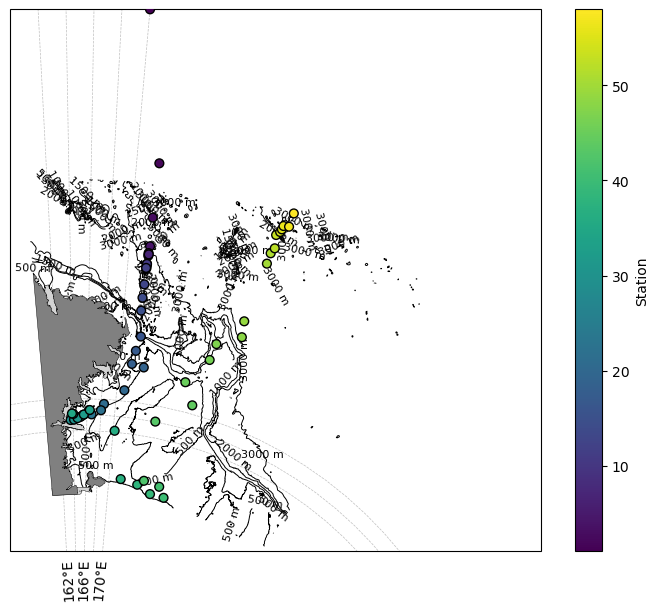

In [20]:
fig, ax = TNB_study_site(
    bath=bath,
    ice=ice,
    land=land,
    lon_min=160,
    lon_max=200,
    lat_min=-78,
    lat_max=-60,
    contour_levels=[500, 1000, 1500, 2000, 3000],
    gridline_lats=[-75.6, -75.0, -74.4],
    gridline_lons=[162, 164, 166, 168, 170],
)


stations = list(casts.keys())
lons = [float(ds.lon) for ds in casts.values()]
lats = [float(ds.lat) for ds in casts.values()]

sc = ax.scatter(
    lons,
    lats,
    c=stations,
    cmap='viridis',
    s=40,
    edgecolor='k',
    transform=ccrs.PlateCarree(),
    zorder=10
)

plt.colorbar(sc, ax=ax, label='Station')

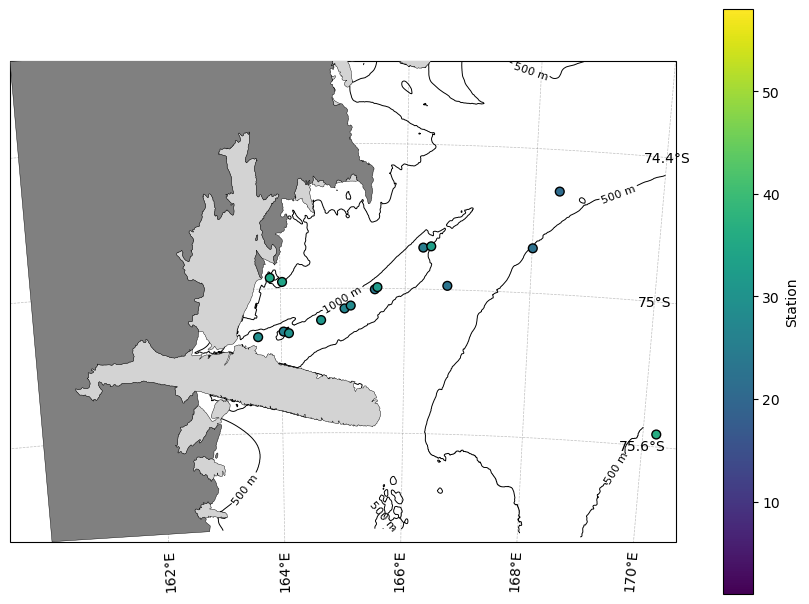

In [21]:
fig, ax = TNB_study_site(
    bath=bath,
    ice=ice,
    land=land,
    lon_min=160,
    lon_max=170,
    lat_min=-76,
    lat_max=-74,
    contour_levels=[500, 1000, 1500, 2000, 3000],
    gridline_lats=[-75.6, -75.0, -74.4],
    gridline_lons=[162, 164, 166, 168, 170],
)

stations = list(casts.keys())
lons = [float(ds.lon) for ds in casts.values()]
lats = [float(ds.lat) for ds in casts.values()]

sc = ax.scatter(
    lons,
    lats,
    c=stations,
    cmap='viridis',
    s=40,
    edgecolor='k',
    transform=ccrs.PlateCarree(),
    zorder=10
)

# ax.text(
#     lon,
#     lat,
#     str(station),
#     transform=ccrs.PlateCarree(),
#     fontsize=8,
#     ha='left',
#     va='bottom',
#     zorder=11
# )

plt.colorbar(sc, ax=ax, label='Station')

In [58]:
casts[30]

<xarray.Dataset> Size: 116kB
Dimensions:      (press: 1039)
Coordinates:
  * press        (press) int64 8kB 3 4 5 6 7 8 ... 1036 1037 1038 1039 1040 1041
    lat          float64 8B -75.18
    lon          float64 8B 164.1
    time         datetime64[ns] 8B 2017-05-09T07:27:50.399999744
    station      int64 8B 30
Data variables: (12/13)
    depth        (press) float64 8kB 2.97 3.96 4.95 ... 1.027e+03 1.028e+03
    temp         (press) float64 8kB -1.913 -1.91 -1.913 ... -1.884 -1.884
    cond         (press) float64 8kB 2.72 2.72 2.72 2.72 ... 2.778 2.778 2.778
    O2           (press) float64 8kB 7.34 7.342 7.342 ... 6.789 6.788 6.791
    theta        (press) float64 8kB -1.913 -1.91 -1.913 ... -1.915 -1.915
    sal          (press) float64 8kB 34.7 34.7 34.7 34.7 ... 34.83 34.83 34.83
    ...           ...
    fluor        (press) float64 8kB 0.033 0.013 0.003 ... 0.043 0.054 0.038
    PAR          (press) float64 8kB 0.0545 0.0347 0.0314 ... 0.000783 0.000792
    beam_trans   (press) float64 8kB 98.2 98.16 98.14 ... 98.03 98.04 98.01
    beam_atten   (press) float64 8kB 0.0727 0.0742 0.0749 ... 0.0793 0.0805
    FLBB1        (press) float64 8kB nan nan nan nan nan ... nan nan nan nan nan
    FLBB2        (press) float64 8kB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    source_file:  nbp1704_30d.txt
    year:         2017

In [22]:
import xarray as xr
import numpy as np

def casts_to_station_dataset(casts):
    ds_list = []

    for station, ds in casts.items():

        # rename press dimension to sample, but keep press as a coordinate
        prof = ds.rename({"press": "sample"})

        prof = prof.assign_coords(
            station=station,
            press=("sample", ds["press"].values)
        )

        # add station dimension
        prof = prof.expand_dims("station")

        ds_list.append(prof)

    combined = xr.concat(ds_list, dim="station")

    return combined

In [23]:
ctd = casts_to_station_dataset(casts)

C:\Users\mblan\AppData\Local\Temp\ipykernel_21284\3141579098.py:22: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'sample' ('sample',) The recommendation is to set join explicitly for this case.
  combined = xr.concat(ds_list, dim="station")
C:\Users\mblan\AppData\Local\Temp\ipykernel_21284\3141579098.py:22: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  combined = xr.concat(ds_list, dim="station")


In [25]:
# select lat and lon to get TNB subset 
lon_min, lon_max = 162, 170
lat_min, lat_max = -75.75, -74.25

In [26]:
ctd_tnb = ctd.where(
    (ctd.lon >= lon_min) &
    (ctd.lon <= lon_max) &
    (ctd.lat >= lat_min) &
    (ctd.lat <= lat_max),
    drop=True
)

In [27]:
ctd_tnb

<xarray.Dataset> Size: 7MB
Dimensions:      (station: 15, sample: 3918)
Coordinates:
  * station      (station) int64 120B 21 22 23 24 25 26 27 ... 30 31 32 33 34 35
  * sample       (sample) int64 31kB 1 2 3 4 5 6 ... 3914 3915 3916 3917 3918
    lat          (station) float64 120B -74.57 -74.81 -74.98 ... -74.97 -74.95
    lon          (station) float64 120B 168.4 168.0 166.7 ... 166.4 164.0 163.8
    time         (station) datetime64[ns] 120B 2017-04-29T15:56:09.600000 ......
    press        (station, sample) float64 470kB nan 2.0 3.0 4.0 ... nan nan nan
Data variables: (12/13)
    depth        (station, sample) float64 470kB nan 1.98 2.97 ... nan nan nan
    temp         (station, sample) float64 470kB nan -1.889 -1.888 ... nan nan
    cond         (station, sample) float64 470kB nan 2.706 2.706 ... nan nan nan
    O2           (station, sample) float64 470kB nan 7.684 7.694 ... nan nan nan
    theta        (station, sample) float64 470kB nan -1.889 -1.888 ... nan nan
    sal          (station, sample) float64 470kB nan 34.49 34.49 ... nan nan nan
    ...           ...
    fluor        (station, sample) float64 470kB nan 0.125 0.121 ... nan nan nan
    PAR          (station, sample) float64 470kB nan 0.115 0.0994 ... nan nan
    beam_trans   (station, sample) float64 470kB nan 98.77 98.83 ... nan nan nan
    beam_atten   (station, sample) float64 470kB nan 0.0494 0.0469 ... nan nan
    FLBB1        (station, sample) float64 470kB nan nan nan nan ... nan nan nan
    FLBB2        (station, sample) float64 470kB nan nan nan nan ... nan nan nan
Attributes:
    source_file:  nbp1704_01d.txt
    year:         2017

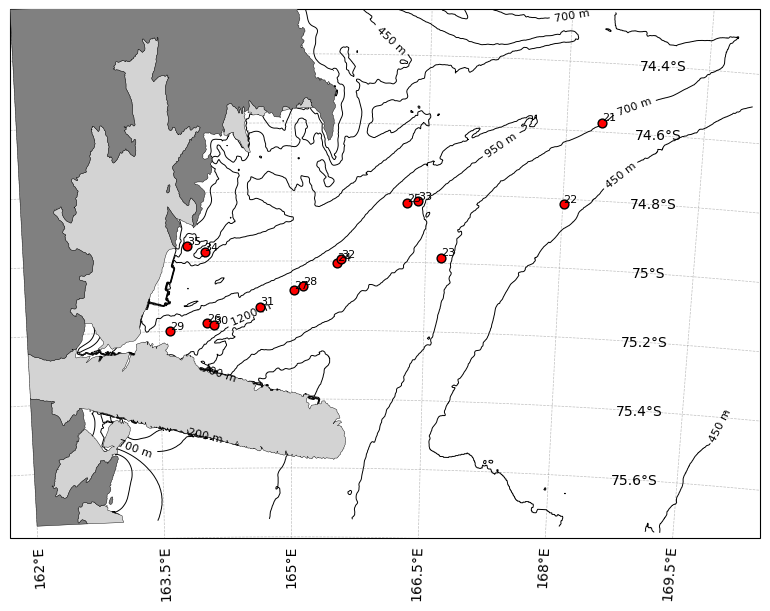

In [28]:
fig, ax = TNB_study_site(
    bath=bath,
    ice=ice,
    land=land,
    lon_min=162,
    lon_max=170,
    lat_min=-75.75,
    lat_max=-74.25
)

# Plot stations
ax.scatter(
    ctd_tnb.lon,
    ctd_tnb.lat,
    s=40,
    color='red',
    edgecolor='k',
    transform=ccrs.PlateCarree(),
    zorder=10
)

# Add station labels
for station in ctd_tnb.station.values:
    
    lon = float(ctd_tnb.sel(station=station).lon)
    lat = float(ctd_tnb.sel(station=station).lat)
    
    ax.text(
        lon,
        lat,
        str(station),
        transform=ccrs.PlateCarree(),
        fontsize=8,
        ha='left',
        va='bottom',
        zorder=11
    )

In [29]:
ctd_tnb

<xarray.Dataset> Size: 7MB
Dimensions:      (station: 15, sample: 3918)
Coordinates:
  * station      (station) int64 120B 21 22 23 24 25 26 27 ... 30 31 32 33 34 35
  * sample       (sample) int64 31kB 1 2 3 4 5 6 ... 3914 3915 3916 3917 3918
    lat          (station) float64 120B -74.57 -74.81 -74.98 ... -74.97 -74.95
    lon          (station) float64 120B 168.4 168.0 166.7 ... 166.4 164.0 163.8
    time         (station) datetime64[ns] 120B 2017-04-29T15:56:09.600000 ......
    press        (station, sample) float64 470kB nan 2.0 3.0 4.0 ... nan nan nan
Data variables: (12/13)
    depth        (station, sample) float64 470kB nan 1.98 2.97 ... nan nan nan
    temp         (station, sample) float64 470kB nan -1.889 -1.888 ... nan nan
    cond         (station, sample) float64 470kB nan 2.706 2.706 ... nan nan nan
    O2           (station, sample) float64 470kB nan 7.684 7.694 ... nan nan nan
    theta        (station, sample) float64 470kB nan -1.889 -1.888 ... nan nan
    sal          (station, sample) float64 470kB nan 34.49 34.49 ... nan nan nan
    ...           ...
    fluor        (station, sample) float64 470kB nan 0.125 0.121 ... nan nan nan
    PAR          (station, sample) float64 470kB nan 0.115 0.0994 ... nan nan
    beam_trans   (station, sample) float64 470kB nan 98.77 98.83 ... nan nan nan
    beam_atten   (station, sample) float64 470kB nan 0.0494 0.0469 ... nan nan
    FLBB1        (station, sample) float64 470kB nan nan nan nan ... nan nan nan
    FLBB2        (station, sample) float64 470kB nan nan nan nan ... nan nan nan
Attributes:
    source_file:  nbp1704_01d.txt
    year:         2017

In [32]:
import matplotlib.pyplot as plt

def plot_ctd_profiles(ctd_tnb):
    fig, axes = plt.subplots(
        nrows=1, ncols=3,
        figsize=(10, 6),
        sharey=True,
        constrained_layout=True
    )

    variables = ["theta", "sal", "sigma_theta"]
    labels = [
        "Temperature (°C)",
        "Salinity (psu)",
        r"$\sigma_\theta$ (kg m$^{-3}$)"
    ]

    for ax, var, label in zip(axes, variables, labels):

        for station in ctd_tnb.station.values:
            ds = ctd_tnb.sel(station=station)

            ax.plot(
                ds[var],
                ds["press"],
                lw=1,
                alpha=0.8,
                label=str(station)
            )

        ax.set_xlabel(label)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Pressure (db)")
    axes[0].invert_yaxis()

    # One shared legend outside plot
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="Station",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8
    )

    return fig, axes

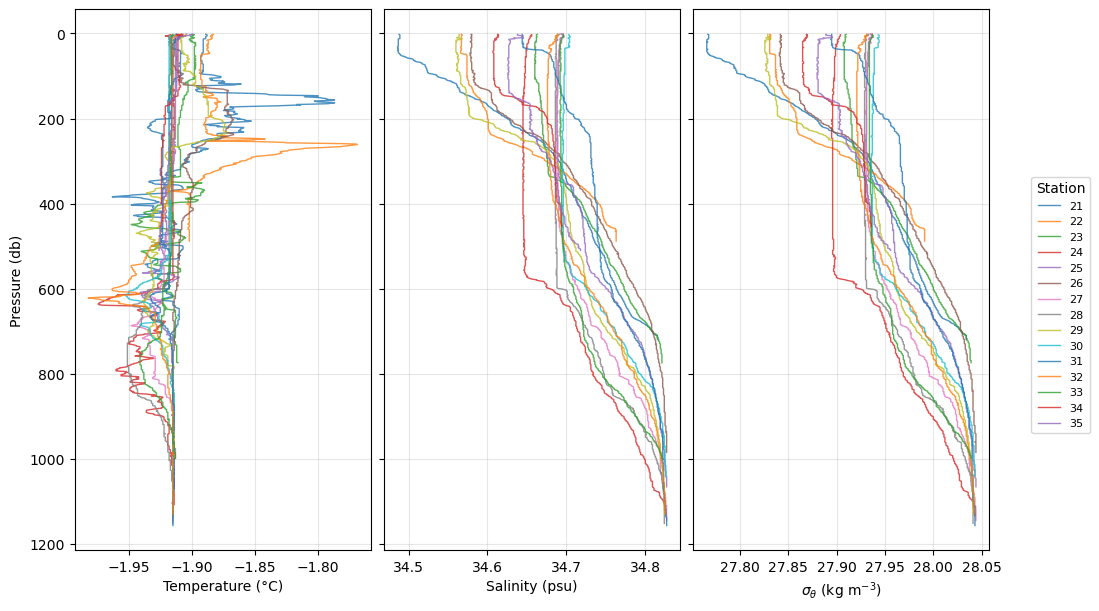

In [33]:
fig, axes = plot_ctd_profiles(ctd_tnb)

In [34]:
import matplotlib.pyplot as plt

def plot_ctd_profile(ctd_tnb, station):
    ds = ctd_tnb.sel(station=station)

    fig, axes = plt.subplots(
        nrows=1, ncols=3,
        figsize=(10, 6),
        sharey=True,
        constrained_layout=True
    )

    variables = ["temp", "sal", "sigma_theta"]
    labels = [
        "Temperature (°C)",
        "Salinity (psu)",
        r"$\sigma_\theta$ (kg m$^{-3}$)"
    ]

    for ax, var, label in zip(axes, variables, labels):

        ax.plot(
            ds[var],
            ds["press"],
            color='k',
            lw=2
        )

        ax.set_xlabel(label)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Pressure (db)")
    axes[0].invert_yaxis()

    fig.suptitle(f"CTD Station {station}", fontsize=12)

    return fig, axes

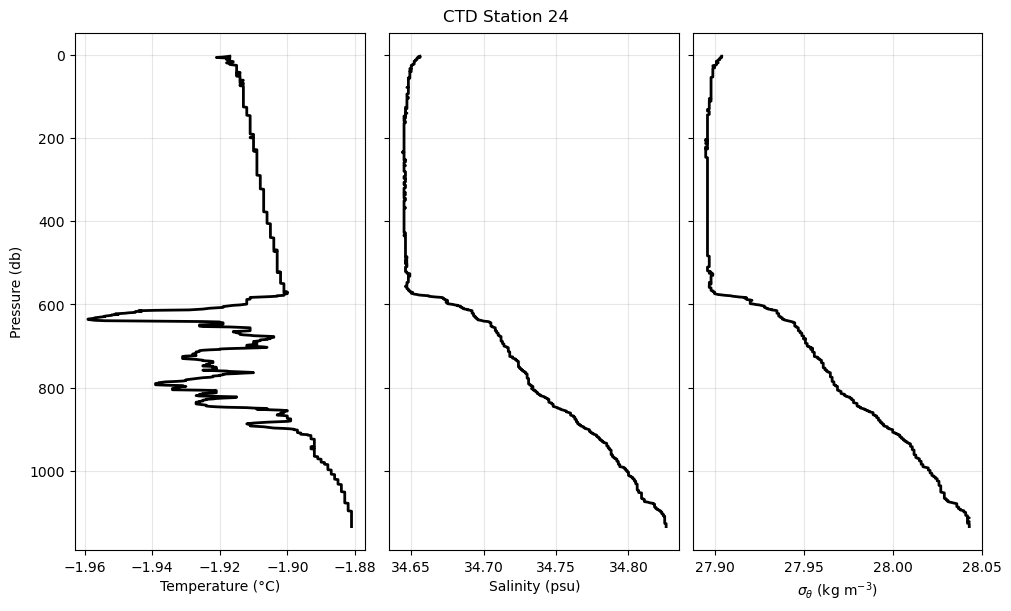

In [42]:
fig, axes = plot_ctd_profile(ctd_tnb, station=24)